In [1]:
from src.scan_fcts import *
from src.load_params import *
from astropy.io import fits

P = load_params('PAR_files/params_jacknife_test.par')

#The coordinates of the field
name=P['name_field']
c=SkyCoord.from_name(name)
ra = 0 
rafield = c.ra.value
dec = c.dec.value

#load the observer position
lat = P['latitude']

#Load the resolution. 
#if not in params, load it from the map used to generate the TOD. 
res = P['res']
if(res is None):
    hdr = fits.getheader(P['path']+P['file'])
    res = (hdr['CDELT1'] * u.Unit(hdr['CUNIT1'])).to(u.deg).value

#Angle of the rotation to apply to the detector array. 
theta = np.radians(P['theta'])

dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 

Text(0.5, 0, 'RA [deg]')

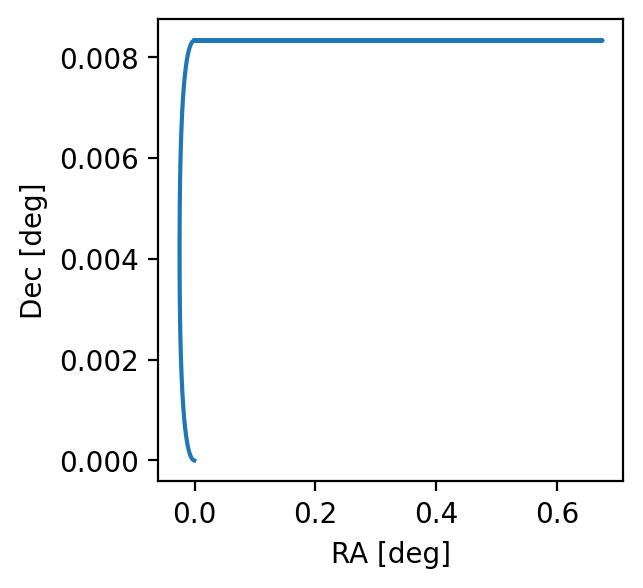

In [2]:
az, alt, flag, t = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
fig, ax = plt.subplots(1,1,figsize=(3,3), dpi=200)  
ax.plot(az,alt)
ax.set_ylabel('Dec [deg]')
ax.set_xlabel('RA [deg]')


3000 3000


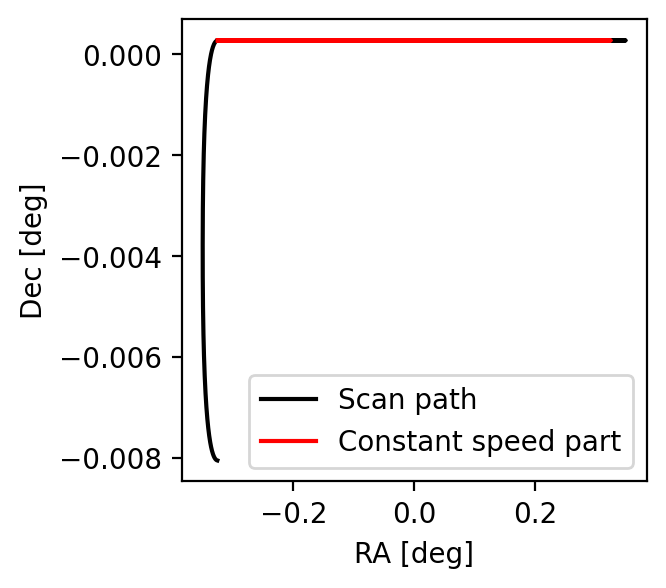

In [3]:
#local sideral time
n = 1
LST = np.arange(-n*t.max()/2,n*t.max()/2+np.round(dt*3600,3),np.round(dt*3600,3)) /3600 #hours
T = np.arange(0,n*t.max()+np.round(dt*3600,3)*0.5,np.round(dt*3600,3))  #hours
scan_path, scan_flag = genScanPath(T, alt, az, flag)
print(len(T), len(LST))

fig, ax = plt.subplots(1,1,figsize=(3,3), dpi=200)  
ax.plot(scan_path[:,0], scan_path[:,1], 'k', label='Scan path')
scan_path = scan_path[scan_flag==1] #Use the scan flag to keep only the constant scan speed part of the pointing. 
T_trim = T[scan_flag==1]
LST_trim = LST[scan_flag==1]
ax.plot(scan_path[:,0], scan_path[:,1], 'r', label='Constant speed part')

ax.set_ylabel('Dec [deg]')
ax.set_xlabel('RA [deg]')
ax.legend()


for v=0.05 deg/s, the step is 0.5"


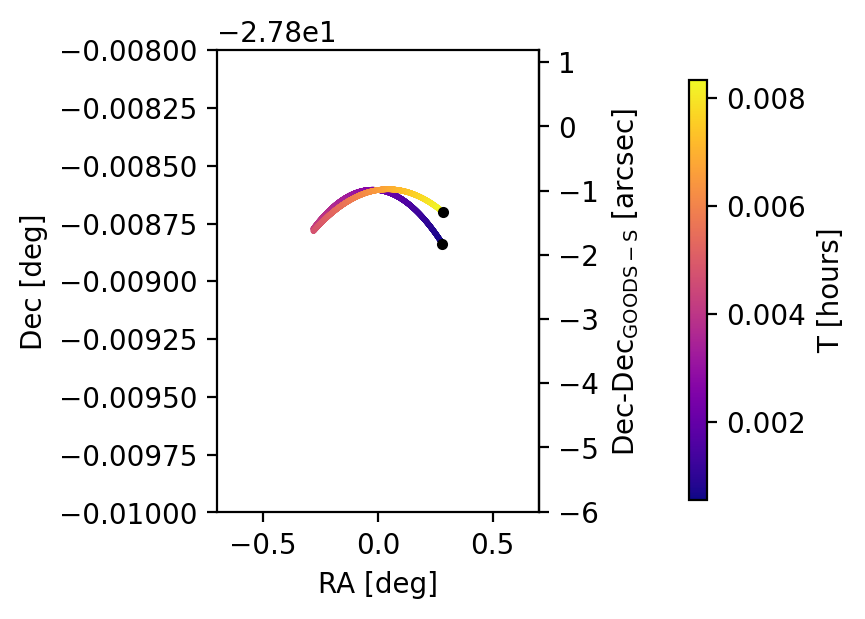

In [4]:
#Generate the pointing on the sky for the center of the arrays
scan_path_sky, azel = genPointingPath(T_trim, scan_path, LST_trim, lat, dec, ra, azel=True) 

fig, ax = plt.subplots(1,1,figsize=(3,3), dpi=200)  
#ax.plot(scan_path_sky[:,0]-dec, scan_path_sky[:,1])
ax.plot(scan_path_sky[0,0], scan_path_sky[0,1], 'ok', markersize=3)
ax.plot(scan_path_sky[-1,0], scan_path_sky[-1,1], 'ok', markersize=3)
sc = ax.scatter(scan_path_sky[:,0], scan_path_sky[:,1], c=T_trim[:]/3600, cmap='plasma', s=1)

ax.set_xlim(-0.7,0.7)
ax.set_ylim(-27.81,-27.808)
def degrees_to_arcsec(x): return (x-dec)*3600
secax = ax.secondary_yaxis("right", functions=(degrees_to_arcsec,degrees_to_arcsec))
fig.tight_layout()
ax.set_ylabel('Dec [deg]')
ax.set_xlabel('RA [deg]')
secax.set_ylabel('Dec-$\\rm Dec_{GOODS-S}$ [arcsec]')
# Add colorbar manually, more to the right
# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([1.1, 0.15, 0.03, 0.7])  # Adjust left as needed (default is ~0.85)
cbar = plt.colorbar(sc, cax=cbar_ax)
cbar.set_label('T [hours]')

dec_step = np.abs(scan_path_sky[0,1]-scan_path_sky[-1,1])

print(f'for v={P["scan_v"]} deg/s, the step is {dec_step*3600:.1f}"')

In [5]:
v_list = (0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045, 0.05 )
alt_size_list = (0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2)
acc_list = (0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045,0.05)

In [6]:
delta_dec_v = []
for v, a in zip(v_list, (0.5,   1.1,   1.1,   1.1,   1.,    1,     1,     1.1,   1.1,   0.5)):

    az, alt, flag, t = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=v, dt=np.round(dt*3600,3))
    #local sideral time
    n = 1
    LST = np.arange(-n*t.max()/2,n*t.max()/2+np.round(dt*3600,3),np.round(dt*3600,3)) /3600 #hours
    T = np.arange(0,n*t.max()+np.round(dt*3600,3)*a,np.round(dt*3600,3))  #hours
    scan_path, scan_flag = genScanPath(T, alt, az, flag)
    scan_path = scan_path[scan_flag==1] #Use the scan flag to keep only the constant scan speed part of the pointing. 
    T_trim = T[scan_flag==1]
    LST_trim = LST[scan_flag==1]
    #Generate the pointing on the sky for the center of the arrays
    scan_path_sky, azel = genPointingPath(T_trim, scan_path, LST_trim, lat, dec, ra, azel=True) 
    dec_step = np.abs(scan_path_sky[0,1]-scan_path_sky[-1,1])
    #print(f'for v={v} deg/s, the step is {dec_step*3600:.1f}"')
    delta_dec_v.append(dec_step*3600)

delta_dec_acc = []
for acc, a in zip(acc_list, (0.5,   0.5,   1.1,   0.5,  0.5,  0.5,   0.5,     0.5,   0.5,   0.5)):

    az, alt, flag, t = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['az_size'], alt_step=P['alt_step'], acc=acc, scan_v=P['scan_v'], dt=np.round(dt*3600,3))
    #local sideral time
    n = 1
    LST = np.arange(-n*t.max()/2,n*t.max()/2+np.round(dt*3600,3),np.round(dt*3600,3)) /3600 #hours
    T = np.arange(0,n*t.max()+np.round(dt*3600,3)*a,np.round(dt*3600,3))  #hours
    #print(T.shape,LST.shape)
    scan_path, scan_flag = genScanPath(T, alt, az, flag)
    scan_path = scan_path[scan_flag==1] #Use the scan flag to keep only the constant scan speed part of the pointing. 
    T_trim = T[scan_flag==1]
    LST_trim = LST[scan_flag==1]
    #Generate the pointing on the sky for the center of the arrays
    scan_path_sky, azel = genPointingPath(T_trim, scan_path, LST_trim, lat, dec, ra, azel=True) 
    dec_step = np.abs(scan_path_sky[0,1]-scan_path_sky[-1,1])
    #print(f'for v={v} deg/s, the step is {dec_step*3600:.1f}"')
    delta_dec_acc.append(dec_step*3600)

delta_dec_az = []
for azsize, a in zip(alt_size_list, (0.5,   0.5,   0.5,   0.5,  0.5,  0.5,   0.5,     0.5,   0.5,   0.5)):

    az, alt, flag, t = genLocalPath_cst_el_scan(az_size=azsize, alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
    #local sideral time
    n = 1
    LST = np.arange(-n*t.max()/2,n*t.max()/2+np.round(dt*3600,3),np.round(dt*3600,3)) /3600 #hours
    T = np.arange(0,n*t.max()+np.round(dt*3600,3)*a,np.round(dt*3600,3))  #hours
    scan_path, scan_flag = genScanPath(T, alt, az, flag)
    scan_path = scan_path[scan_flag==1] #Use the scan flag to keep only the constant scan speed part of the pointing. 
    T_trim = T[scan_flag==1]
    LST_trim = LST[scan_flag==1]
    #Generate the pointing on the sky for the center of the arrays
    scan_path_sky, azel = genPointingPath(T_trim, scan_path, LST_trim, lat, dec, ra, azel=True) 
    dec_step = np.abs(scan_path_sky[0,1]-scan_path_sky[-1,1])
    #print(f'for v={v} deg/s, the step is {dec_step*3600:.1f}"')
    delta_dec_az.append(dec_step*3600)


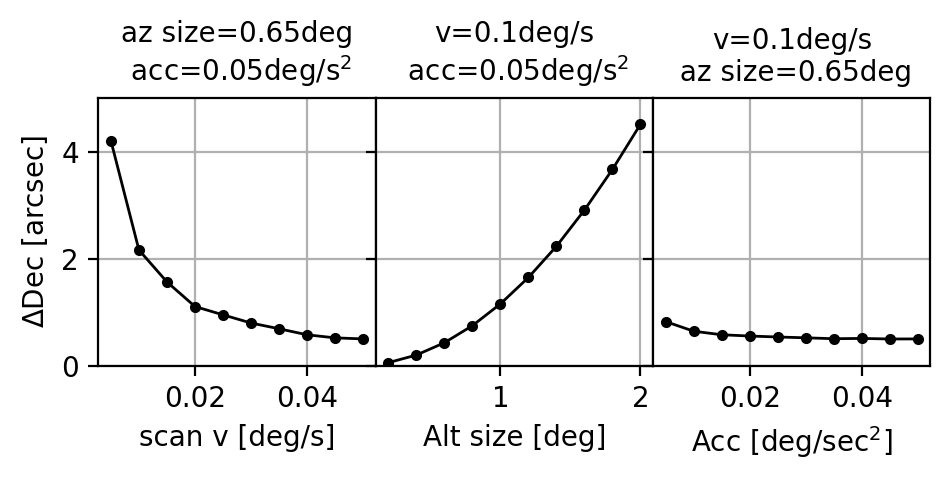

In [13]:
fig, (ax, axaz,axacc) = plt.subplots(1,3,figsize=(5,2.5), dpi=200, sharey = True)  
ax.plot(v_list,delta_dec_v, 'ok', markersize=3)
ax.plot(v_list,delta_dec_v, 'k',lw=1)
ax.set_ylabel('$\\rm \\Delta$Dec [arcsec]')
ax.set_xlabel('scan v [deg/s]')
ax.set_title(f'az size={P["az_size"]}deg\n acc={P["acc"]}$\\rm deg/s^2$', fontsize=10)
ax.set_ylim(0,5)
ax.grid()

axaz.plot(alt_size_list,delta_dec_az, 'ok', markersize=3)
axaz.plot(alt_size_list,delta_dec_az, 'k',lw=1)
axaz.set_xlabel('Alt size [deg]')
axaz.set_title(f'v={P["scan_v"]:.1f}deg/s\n acc={P["acc"]}$\\rm deg/s^2$', fontsize=10)
axaz.set_ylim(0,5)
axaz.grid()

axacc.plot(acc_list,delta_dec_acc, 'ok', markersize=3)
axacc.plot(acc_list,delta_dec_acc, 'k',lw=1)
axacc.set_xlabel('Acc [deg$\\rm /sec^2$]')
axacc.set_title(f'v={P["scan_v"]:.1f}deg/s\n az size={P["az_size"]}deg', fontsize=10)
axacc.set_ylim(0,5)
axacc.grid()

fig.tight_layout()
fig.subplots_adjust(wspace=0)